In [153]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [154]:
def get_difference(
    file_path,
    side1_products,
    side1_scalars,
    side2_products,
    side2_scalars,
) -> pd.DataFrame:

    if len(side1_products) != len(side1_scalars):
        raise ValueError("side1_products and side1_scalars must have the same length")
    if len(side2_products) != len(side2_scalars):
        raise ValueError("side2_products and side2_scalars must have the same length")

    df = pd.read_csv(file_path, sep=";")

    # Clean numeric columns
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["mid_price"] = pd.to_numeric(df["mid_price"], errors="coerce")
    df = df.dropna(subset=["timestamp", "product", "mid_price"])

    # Build a pivot table: rows = timestamp, columns = product, values = mid_price
    # If there are duplicates for a timestamp/product, take the last observed value.
    pivot = df.pivot_table(
        index="timestamp",
        columns="product",
        values="mid_price",
        aggfunc="last",
    ).sort_index()

    # Compute weighted sums for each side
    side1_value = pd.Series(0.0, index=pivot.index)
    for product, scalar in zip(side1_products, side1_scalars):
        if product not in pivot.columns:
            raise KeyError(f"Product '{product}' not found in market file")
        side1_value = side1_value + pivot[product].fillna(0) * scalar

    side2_value = pd.Series(0.0, index=pivot.index)
    for product, scalar in zip(side2_products, side2_scalars):
        if product not in pivot.columns:
            raise KeyError(f"Product '{product}' not found in market file")
        side2_value = side2_value + pivot[product].fillna(0) * scalar

    difference = side1_value - side2_value
    difference_df = difference.reset_index()
    difference_df.columns = ["timestamp", "mid_price"]
    return difference_df

In [155]:
def plot_difference(
        difference: pd.DataFrame,
        title="Basket Premium / Difference vs Timestamp",
    ):

    # DEBUG
    print(difference["mid_price"].mean() - difference["mid_price"].std())
    print(difference["mid_price"].mean())    
    print(difference["mid_price"].mean() + difference["mid_price"].std())

    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(difference["timestamp"], difference["mid_price"], linewidth=0.8)
    plt.axhline(difference["mid_price"].mean() - difference["mid_price"].std(), linestyle="--", linewidth=0.8)
    plt.axhline(difference["mid_price"].mean(), linestyle="--", linewidth=0.8)
    plt.axhline(difference["mid_price"].mean() + difference["mid_price"].std(), linestyle="--", linewidth=0.8)
    plt.title(title)
    plt.xlabel("Timestamp")
    plt.ylabel("Price Difference")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [156]:
def auto_correlation(df: pd.DataFrame, column1: str, column2: str, lag: int = 1) -> float:
    if column1 not in df.columns:
        raise KeyError(f"df must contain a '{column1}' column")
    if column2 not in df.columns:
        raise KeyError(f"df must contain a '{column2}' column")

    tmp = df[[column1, column2]].copy().sort_values(column1)
    x = tmp[column2]
    y = tmp[column2].shift(lag)
    return x.corr(y)

C:\Users\ishaa\AppData\Local\Temp\ipykernel_25388\206958766.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  full_df = pd.concat([full_df, df])


-29.613233555985698
30.235966666666666
90.08516688931903


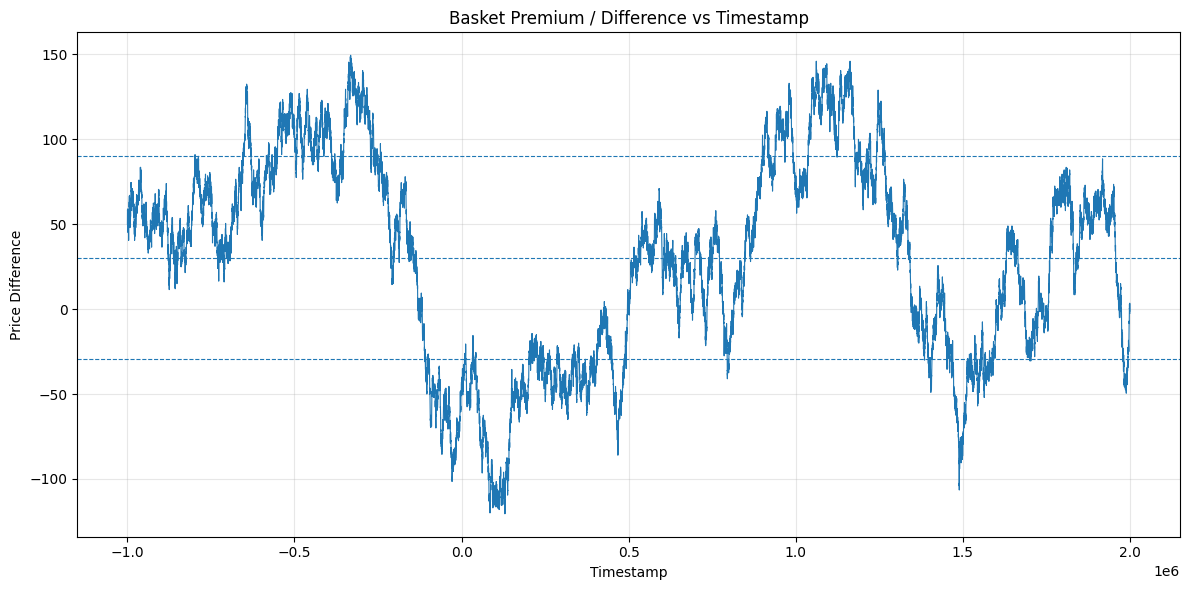

In [159]:
full_df = pd.DataFrame(columns=["timestamp", "mid_price"])
first_day = -1

for day in range(first_day, first_day + 3):
    file_path = "r2_d" + str(day) + ".csv"
    df = pd.read_csv(file_path, sep=";")
    df.index = df.index + 80000 * (day - first_day)
    df["timestamp"] = df["timestamp"] + 1000000 * day
    full_df = pd.concat([full_df, df])

# print(full_df)

'''
PARAMETERS
'''

df = full_df # for method below, since it uses df
side1_products = ["PICNIC_BASKET2"]
side1_scalars = [1]
side2_products = ["CROISSANTS", "JAMS"]
side2_scalars = [4, 2]
    
'''
START OF METHOD
'''

# Clean numeric columns
df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
df["mid_price"] = pd.to_numeric(df["mid_price"], errors="coerce")
df = df.dropna(subset=["timestamp", "product", "mid_price"])

# Build a pivot table: rows = timestamp, columns = product, values = mid_price
# If there are duplicates for a timestamp/product, take the last observed value.
pivot = df.pivot_table(
    index="timestamp",
    columns="product",
    values="mid_price",
    aggfunc="last",
).sort_index()

# Compute weighted sums for each side
side1_value = pd.Series(0.0, index=pivot.index)
for product, scalar in zip(side1_products, side1_scalars):
    if product not in pivot.columns:
        raise KeyError(f"Product '{product}' not found in market file")
    side1_value = side1_value + pivot[product].fillna(0) * scalar

side2_value = pd.Series(0.0, index=pivot.index)
for product, scalar in zip(side2_products, side2_scalars):
    if product not in pivot.columns:
        raise KeyError(f"Product '{product}' not found in market file")
    side2_value = side2_value + pivot[product].fillna(0) * scalar

difference = side1_value - side2_value
difference_df = difference.reset_index()
difference_df.columns = ["timestamp", "mid_price"]
# print(difference_df)

'''
END OF METHOD
'''

difference_df["shifted_price"] = difference_df["mid_price"].shift(-1)
difference_df["shifted_diff"] = (difference_df["mid_price"].shift(-1) - difference_df["mid_price"])
# print(difference_df)

# this is bs.
acs = [auto_correlation(difference_df, "mid_price", "shifted_diff", i) for i in range(100, 5100, 100)]
acs = np.array(acs)
# print(acs.mean())
plot_difference(difference_df)